# 03 — Improving the model properly

Goal: improve on the notebook 02 baseline **without fooling ourselves**.

Rule for this notebook: the **test set is locked**. Every decision (features, settings,
threshold) is made using the training set only. The test set is used exactly once, in step 7.

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_val_predict,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline

DATA_PATH = Path("..") / "data" / "fake_job_postings.csv"
MODEL_DIR = Path("..") / "models"
RANDOM_STATE = 42

## 1. Re-create the exact train/test split from notebook 02

Same steps in the same order — combine text, drop duplicates, split 80/20 stratified with
`random_state=42` — so the rows land in exactly the same train and test sets as before.

In [2]:
df = pd.read_csv(DATA_PATH)

TEXT_COLUMNS = ["title", "company_profile", "description", "requirements", "benefits"]
df["text"] = df[TEXT_COLUMNS].fillna("").agg(" ".join, axis=1)
df = df.drop_duplicates(subset="text", keep="first").reset_index(drop=True)

## 2. Add metadata features

Metadata = facts *about* the posting rather than its words. Three already exist as 1/0;
we build two more:

- **`salary_listed`** — notebook 01 showed fakes list a salary *more* often (26% vs. 16%), possibly as bait.
- **`has_company_profile`** — real employers usually describe themselves; scammers often skip it.
  The profile's words are already in `text`, but "there is no profile at all" is hard for the
  model to see from words alone, so a direct yes/no column makes the *absence* a clue.

In [3]:
df["salary_listed"] = df["salary_range"].notna().astype(int)
df["has_company_profile"] = df["company_profile"].notna().astype(int)

METADATA_COLUMNS = [
    "has_company_logo",
    "has_questions",
    "telecommuting",
    "salary_listed",
    "has_company_profile",
]

# How often each feature is 1, for real vs. fake postings (whole dataset, before splitting).
(df.groupby("fraudulent")[METADATA_COLUMNS].mean() * 100).round(1).rename(index={0: "real %", 1: "fake %"})

,has_company_logo,has_questions,telecommuting,salary_listed,has_company_profile
fraudulent,,,,,
real %,81.9,49.6,4.1,16.3,83.0
fake %,35.0,31.8,7.4,27.0,34.1


**What this tells us:** Our new `has_company_profile` column separates real from fake about as sharply as the logo does (83% of real postings have a profile vs. 34% of fakes), and `salary_listed` confirms fakes list pay more often. On their own these look like strong clues, but the model already reads the text, so the real question — answered in step 4 — is whether they add anything the words don't already say.

In [4]:
# Same split as notebook 02. X keeps the text plus the metadata columns.
X = df[["text"] + METADATA_COLUMNS]
y = df["fraudulent"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

for name, part in [("Train", y_train), ("Test", y_test)]:
    print(f"{name}: {len(part):,} postings, {part.mean() * 100:.2f}% fake")
print("\nExpected from notebook 02: Train 12,852 (4.47%), Test 3,214 (4.48%)")

# 🔒 From here until step 7, X_test / y_test are not used.

Train: 12,852 postings, 4.47% fake
Test: 3,214 postings, 4.48% fake

Expected from notebook 02: Train 12,852 (4.47%), Test 3,214 (4.48%)


## 3. Build the Pipeline

- **ColumnTransformer** sends each column to the right processing: TF-IDF for `text`,
  metadata **passed through** unchanged (it's already 0/1), then glues the results side by side.
- **Pipeline** chains *processing → model* into one object.

**Why this prevents leakage in cross-validation:** TF-IDF lives *inside* the pipeline, so in each
cross-validation round it is re-fitted from scratch on that round's training folds only. The
held-out fold never influences the vocabulary — the "fit on train only" rule, applied automatically.

In [5]:
def make_pipeline(use_metadata: bool) -> Pipeline:
    """Text TF-IDF (+ optional metadata) -> logistic regression, as one object."""
    transformers = [
        # Passing "text" as a plain string (not a list) hands TF-IDF one column of strings.
        ("text", TfidfVectorizer(ngram_range=(1, 2), max_features=20000), "text"),
    ]
    if use_metadata:
        transformers.append(("meta", "passthrough", METADATA_COLUMNS))

    return Pipeline([
        ("features", ColumnTransformer(transformers)),  # unlisted columns are dropped
        ("model", LogisticRegression(class_weight="balanced", max_iter=1000)),
    ])

make_pipeline(use_metadata=True)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('features', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('meta', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o

## 4. Cross-validation: text only vs. text + metadata

**5-fold stratified cross-validation** on the training set only: split it into 5 parts, train on 4,
score on the 5th, repeat so each part is scored once. Every score is PR-AUC.
**Spread** = standard deviation: how much the score bounces between folds.

In [6]:
# shuffle + random_state makes the folds the same every run.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, use_metadata in [("(a) text only", False), ("(b) text + metadata", True)]:
    scores = cross_val_score(
        make_pipeline(use_metadata), X_train, y_train,
        cv=cv, scoring="average_precision", n_jobs=-1,
    )
    cv_results[name] = scores

cv_table = pd.DataFrame(cv_results, index=[f"fold {i}" for i in range(1, 6)]).T
cv_table["mean"] = cv_table.mean(axis=1)
cv_table["spread (std)"] = cv_table.iloc[:, :5].std(axis=1)
cv_table.round(3)

,fold 1,fold 2,fold 3,fold 4,fold 5,mean,spread (std)
(a) text only,0.800,0.840,0.866,0.854,0.807,0.834,0.029
(b) text + metadata,0.785,0.826,0.824,0.830,0.838,0.820,0.021


**What this tells us:** Adding metadata did *not* help: text + metadata averaged 0.820 vs. 0.834 for text alone, and it scored lower in 4 of 5 folds — although the gap (0.014) is smaller than the fold-to-fold spread, so it is most likely "no real difference" rather than real harm. The likely reason is overlap: a missing company profile already shows up in the text as missing company words, so the yes/no columns mostly repeat what TF-IDF knows; we keep them in the final pipeline as planned, since they cost little and make the model's inputs explicit.

## 5. Grid search: `C` and `ngram_range`

Tries all 6 combinations with the same 5 folds (30 trainings) on the text + metadata pipeline.

**What `C` does:** it sets how much the model may trust individual words.
- **Small C (0.1)** = strong restraint: small weights spread over many clues; less memorising of quirks.
- **Large C (10)** = little restraint: can lean hard on a few specific words; risks **overfitting**
  (learning quirks of this data that don't hold up on new postings).

In [7]:
param_grid = {
    "model__C": [0.1, 1, 10],
    "features__text__ngram_range": [(1, 1), (1, 2)],
}

grid = GridSearchCV(
    make_pipeline(use_metadata=True),
    param_grid,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    refit=True,  # after searching, retrain the best combo on the whole training set
)
grid.fit(X_train, y_train)

results = pd.DataFrame(grid.cv_results_)
grid_table = pd.DataFrame({
    "C": results["param_model__C"],
    "ngram_range": results["param_features__text__ngram_range"].astype(str),
    "mean PR-AUC": results["mean_test_score"].round(3),
    "spread (std)": results["std_test_score"].round(3),
}).sort_values("mean PR-AUC", ascending=False).reset_index(drop=True)

print("Best settings:", grid.best_params_)
grid_table

Best settings: {'features__text__ngram_range': (1, 2), 'model__C': 10}


,C,ngram_range,mean PR-AUC,spread (std)
0,10.0,"(1, 2)",0.879,0.014
1,10.0,"(1, 1)",0.878,0.016
2,1.0,"(1, 2)",0.820,0.018
3,1.0,"(1, 1)",0.818,0.026
4,0.1,"(1, 2)",0.541,0.034
5,0.1,"(1, 1)",0.528,0.034


**What this tells us:** `C` matters far more than n-grams: C=10 scores 0.879 while C=0.1 collapses to about 0.53, and single words vs. word pairs differ by at most 0.013. The model does best with *little* restraint, letting it lean on very specific words — which boosts the score but fits the worry from notebook 02 about memorising company names, and since C=10 is the edge of our grid, a higher C might score higher still (not tried: no further tuning in this task set).

## 6. Choose a decision threshold (training set only)

The model outputs a probability; the **threshold** is the cut-off for calling a posting "fake".
Lower = catch more scams but more false alarms; higher = fewer false alarms but more misses.

To choose fairly without the test set, we use **cross-validated predictions**: every training
posting is scored by a model (best settings from step 5) that did not train on it.

In [8]:
train_probs = cross_val_predict(
    grid.best_estimator_, X_train, y_train,
    cv=cv, method="predict_proba", n_jobs=-1,
)[:, 1]

rows = []
for t in np.round(np.arange(0.2, 0.81, 0.1), 1):
    pred = (train_probs >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision (fake)": precision_score(y_train, pred, zero_division=0),
        "recall (fake)": recall_score(y_train, pred),
        "postings flagged": int(pred.sum()),
    })
threshold_table = pd.DataFrame(rows)
threshold_table.style.format({"threshold": "{:.1f}", "precision (fake)": "{:.1%}", "recall (fake)": "{:.1%}"})

,threshold,precision (fake),recall (fake),postings flagged
0,0.2,49.2%,91.3%,1066
1,0.3,58.9%,88.5%,863
2,0.4,66.3%,86.2%,747
3,0.5,72.6%,81.9%,647
4,0.6,79.2%,78.9%,572
5,0.7,86.4%,75.4%,501
6,0.8,91.5%,69.7%,437


**What this tells us:** Lowering the threshold trades false alarms for caught scams: at 0.2 we catch 91% of scams but half the flags are wrong, while at 0.8 nine in ten flags are right but we miss 30% of scams. **Recommendation: 0.4** — it catches 86% of scams while two of every three flags are genuine, and going lower to 0.3 would gain only ~2 points of recall for ~7 points more false alarms.

In [9]:
# Chosen after reading the table above (cross-validated training predictions only).
# 0.4 keeps recall high (~86%) while two of every three flags are correct.
CHOSEN_THRESHOLD = 0.4

## 7. 🔓 Final evaluation on the test set — run once

The best pipeline (already retrained on the full training set by the grid search) is scored on
the locked test set at the chosen threshold. No changes are made after seeing these numbers.

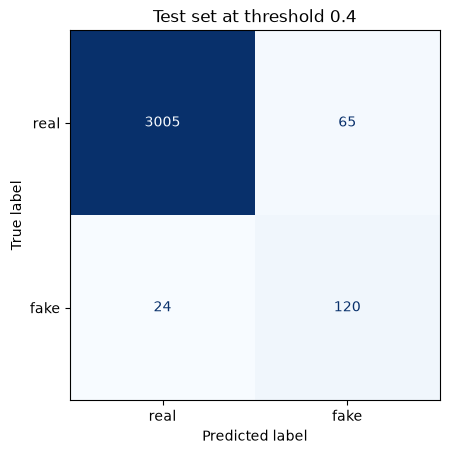

,baseline (nb 02),v1 (this notebook)
precision (fake),0.587,0.649
recall (fake),0.819,0.833
PR-AUC,0.819,0.857


In [10]:
final_pipeline = grid.best_estimator_

if CHOSEN_THRESHOLD is None:
    print("Threshold not chosen yet - test set stays locked.")
else:
    test_probs = final_pipeline.predict_proba(X_test)[:, 1]
    test_pred = (test_probs >= CHOSEN_THRESHOLD).astype(int)

    ConfusionMatrixDisplay(
        confusion_matrix(y_test, test_pred), display_labels=["real", "fake"]
    ).plot(cmap="Blues", colorbar=False)
    plt.title(f"Test set at threshold {CHOSEN_THRESHOLD}")
    plt.show()

    # Notebook 02's baseline numbers (text only, C=1, threshold 0.5), for comparison.
    comparison = pd.DataFrame({
        "baseline (nb 02)": [0.587, 0.819, 0.819],
        "v1 (this notebook)": [
            precision_score(y_test, test_pred),
            recall_score(y_test, test_pred),
            average_precision_score(y_test, test_probs),
        ],
    }, index=["precision (fake)", "recall (fake)", "PR-AUC"])
    display(comparison.round(3))

**What this tells us:** On the never-seen test set, v1 beats the notebook 02 baseline on every measure: PR-AUC 0.857 vs. 0.819, recall 83.3% vs. 81.9% (about 120 of 144 scams caught), and precision 64.9% vs. 58.7% (fewer false alarms). The test PR-AUC is a bit below the cross-validation estimate of 0.879, which is normal and small, so the training-set numbers we used for decisions were a fair guide — this is our honest estimate of v1's quality on postings like these.

## 8. Save the final pipeline

One file holds everything: TF-IDF vocabulary, metadata handling and the model, so raw postings
go in and scam probabilities come out. The threshold is saved alongside it.

In [11]:
if CHOSEN_THRESHOLD is None:
    print("Threshold not chosen yet - nothing saved.")
else:
    MODEL_DIR.mkdir(exist_ok=True)
    model_path = MODEL_DIR / "job_trust_v1.joblib"

    joblib.dump(
        {
            "pipeline": final_pipeline,
            "threshold": CHOSEN_THRESHOLD,
            "text_columns": TEXT_COLUMNS,
            "metadata_columns": METADATA_COLUMNS,
        },
        model_path,
    )
    print(f"Saved {model_path} ({model_path.stat().st_size / 1e6:.1f} MB)")

Saved ../models/job_trust_v1.joblib (1.0 MB)
